In [1]:
import json
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
dataset_dir = f'{parent_dir}/dataset'

with open(f'{dataset_dir}/correct_ids/tracks.json') as f:
    tracks = json.load(f)

In [2]:
texts = list()

for track in tracks:
    texts.append(track['lyrics'])

In [3]:
count = 0
for i in range(len(texts)):
    if not texts[i]:
        count += 1
        texts[i] = ''

count

3

In [4]:
for track in tracks:
    if not track.get('n_tokens') and track.get('lyrics'):
        track['n_tokens'] = len(track['lyrics'].split())
    elif not track.get('n_tokens') and not track.get('lyrics'):
        track['n_tokens'] = 0

In [5]:
# fill meta fields with median
import statistics

def set_missing_to_median(field):
    values = []

    for track in tracks:
        if track.get(field):
            track[field] = float(track[field])
            values.append(float(track[field]))

    median = statistics.median(values)

    for track in tracks:
        if not track.get(field):
            track[field] = median

In [6]:
tracks[0].keys()

dict_keys(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist', 'language', 'album', 'swear_IT', 'swear_EN', 'swear_IT_words', 'swear_EN_words', 'year', 'month', 'day', 'n_sentences', 'n_tokens', 'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type', 'disc_number', 'track_number', 'duration_ms', 'explicit', 'popularity', 'id_album', 'lyrics', 'streams@1month', 'new_id_album', 'new_track_id', 'new_id_artist', 'date_id'])

In [7]:
import ast

swears_it = set()
swears_en = set()

for track in tracks:
    if track.get('swear_IT_words'):
        track['swear_IT_words'] = ast.literal_eval(track['swear_IT_words'])
        swears_it.update(track['swear_IT_words'])
    if track.get('swear_EN_words'):
        track['swear_EN_words'] = ast.literal_eval(track['swear_EN_words'])
        swears_en.update(track['swear_EN_words'])

len(swears_en), len(swears_it)

(96, 173)

In [8]:
for track in tracks:
    if track.get('lyrics'):
        tokenized_lyrics = track['lyrics'].strip().split()
        curr_swears_en = []
        curr_swears_it = []
        for tok in tokenized_lyrics:
            if tok in swears_en:
                curr_swears_en.append(tok)
            if tok in swears_it:
                curr_swears_it.append(tok)
        track['swear_EN_words'] = curr_swears_en
        track['swear_EN'] = len(curr_swears_en)
        track['swear_IT_words'] = curr_swears_it
        track['swear_IT'] = len(curr_swears_it)
        if len(curr_swears_it) > 0 or len(curr_swears_en) > 0:
            track['explicit'] = True
        else:
            track['explicit'] = False
    else:
        track['lyrics'] = ''

In [9]:
# dict_keys(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
#            'language', 'album', 'swear_IT', 'swear_EN', 'swear_IT_words',
#             'swear_EN_words', 'year', 'month', 'day', 'n_sentences', 'n_tokens',
#             'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff', 'flux', 'rms',
#             'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name',
#             'album_release_date', 'album_type', 'disc_number', 'track_number',
#             'duration_ms', 'explicit', 'popularity', 'id_album', 'lyrics',
#             'streams@1month', 'new_id_album', 'new_track_id', 'new_id_artist', 'date_id'])

keys_median = [
    'bpm', 'rolloff', 'flux', 'rms',
    'flatness', 'spectral_complexity', 'pitch',
    'loudness'
]

for key in keys_median:
    track[key] = set_missing_to_median(key)

In [10]:
for track in tracks:
    if not track.get('streams@1month'):
        track['streams@1month'] = 0
    if not track.get('lyrics'):
        track['lyrics'] = ''
    if not track.get('popularity'):
        track['popularity'] = 0

In [11]:
for track in tracks:
    if not track.get('year') and track.get('album_release_date'):
        date = track['album_release_date']
        date = date.strip().split('-')
        track['year'] = date[0]
        if len(date) > 1:
            track['month'] = date[1]
            track['day'] = date[2]

In [12]:
missing_year = []
missing_month = []

for track in tracks:
    if not track.get('year'):
        missing_year.append(track)
    if not track.get('month'):
        missing_month.append(track)
        
len(missing_month), len(missing_year)

(791, 0)

In [ ]:
# with open(f'{dataset_dir}/correct_ids/tracks_filled.json', 'w') as f:
#     json.dump(tracks, f)

In [ ]:
import numpy as np

keys = [
    'bpm', 'year', 'duration_ms',
    'n_tokens', 'pitch', 'loudness'
]

for key in keys:
    set_missing_to_median(key)

meta_arrays = [np.array([float(t[key]) for t in tracks]) for key in keys]


meta = np.column_stack(meta_arrays)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(texts)

num_topics = 50
nmf_model = NMF(n_components=num_topics, random_state=1)
nmf_model.fit(dtm)

topic_vectors = nmf_model.components_

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

W = nmf_model.transform(dtm)
W = StandardScaler().fit_transform(W)

# PCA to topic vector
pca_topics = PCA(n_components=10, random_state = 42)
W = pca_topics.fit_transform(W)

meta_scaled = StandardScaler().fit_transform(meta)

W = np.hstack([W, meta_scaled])

In [9]:
W

array([[-1.07418651,  1.48999014,  2.00472501, ...,  1.97947774,
         0.14466379, -0.73877248],
       [-2.47148445,  1.54949844,  1.08236015, ...,  0.85322962,
        -0.95670066, -0.321948  ],
       [-1.97686475,  3.9763726 ,  1.41383662, ...,  1.24932536,
         0.59987268,  0.60633357],
       ...,
       [-2.11369277, -1.10063284, -0.15906187, ...,  0.35214465,
         2.14296685,  0.14233784],
       [ 0.90657061, -0.60772823,  0.88560695, ..., -0.91727061,
         1.31049656,  0.97040515],
       [-1.80464268, -1.32737922,  1.2770326 , ..., -0.75501452,
         0.8455693 , -1.14292512]], shape=(11166, 16))

In [10]:
count = 0

for track in tracks:
    if (track.get('n_sentences') and track.get('lyrics')):
        if track['n_sentences'] >= len(track['lyrics'].split('\n')) - 10 and track['n_sentences'] <= len(track['lyrics'].split('\n')) + 10:
            count += 1

count

10864

In [11]:
for track in tracks:
    if not track.get('n_sentences') and track.get('lyrics'):
        track['n_sentences'] = len(track['lyrics'].split('\n'))
    elif not track.get('n_sentences') and not track.get('lyrics'):
        track['n_sentences'] = 0

In [12]:
# fill missing popularity with 0
for track in tracks:
    if not track.get('popularity'):
        track['popularity'] = 0

# Clustering

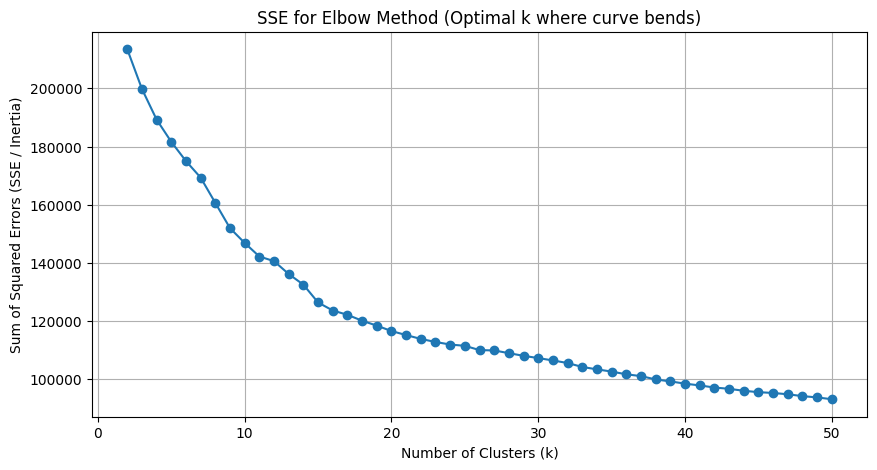

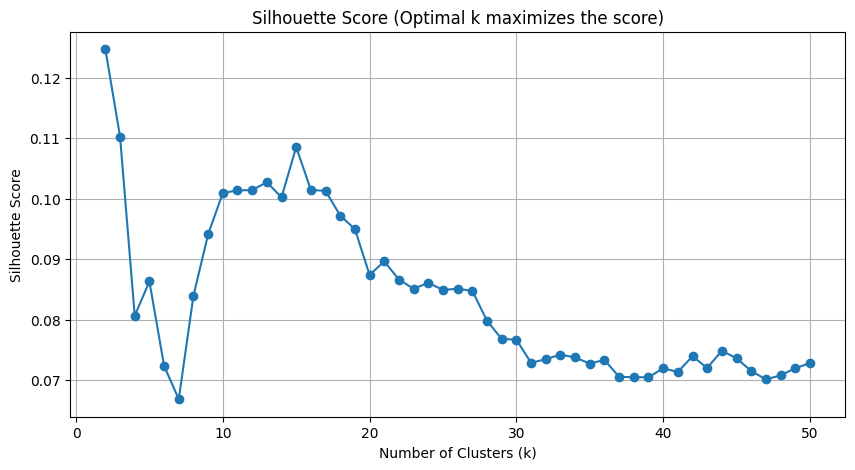

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sse_list = []
silhouette_list = []

k_range = range (2, 51)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(W)
    
    sse_list.append(kmeans.inertia_)
    
    score = silhouette_score(W, kmeans.labels_)
    silhouette_list.append(score)
    
# SSE
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse_list, marker='o')
plt.title('SSE for Elbow Method (Optimal k where curve bends)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE / Inertia)')
plt.grid(True)
plt.show()

# Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_list, marker='o')
plt.title('Silhouette Score (Optimal k maximizes the score)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [14]:
k = 9

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(W)

topic_labels = kmeans.labels_

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

W_pca = pca.fit_transform(W)

df_pca = pd.DataFrame(data=W_pca, columns=['PC1', 'PC2'])

df_pca['Cluster'] = topic_labels

explained_variance = pca.explained_variance_ratio_.sum()

print(f"Total variance explained by these two components: {explained_variance:.2%}")
print("\nDataFrame ready for plotting:")
print(df_pca.head())

PCA reduced the data from 20 dimensions to 2.
Total variance explained by these two components: 27.40%

DataFrame ready for plotting:
        PC1       PC2  Cluster
0 -0.925169  1.721294        5
1 -2.383883  1.511417        8
2 -2.201331  3.947504        1
3 -0.977529  1.839089        1
4 -2.429843  4.193376        8


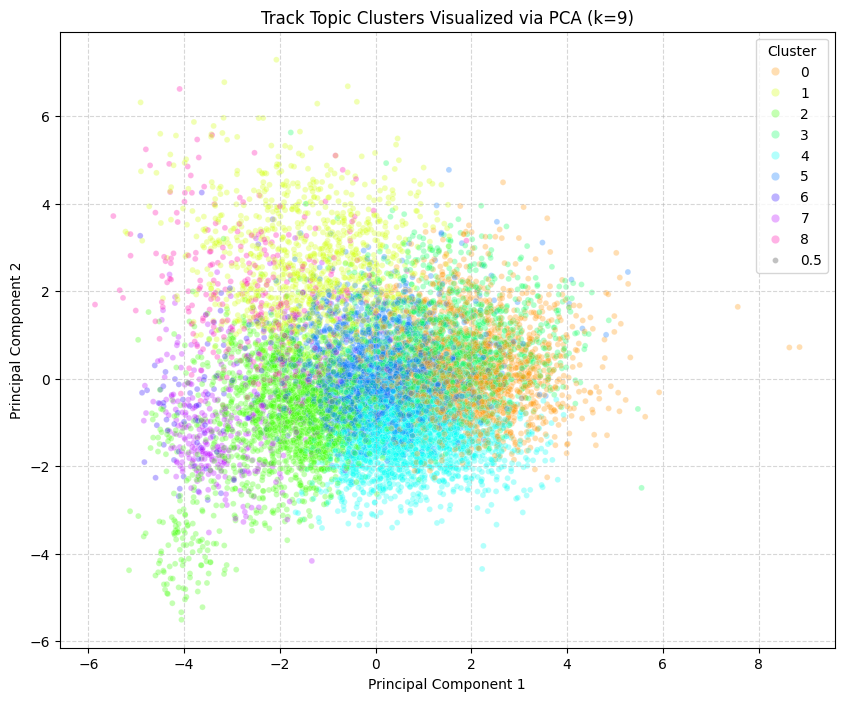

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Use seaborn to create a scatter plot, using the 'Cluster' column to assign colors
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    data=df_pca, 
    palette=sns.color_palette("hsv", n_colors=len(np.unique(topic_labels))), # Ensure distinct colors
    legend="full",
    alpha=0.3 ,
    size=0.5
)

plt.title(f'Track Topic Clusters Visualized via PCA (k={len(np.unique(topic_labels))})')
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('pca_cluster_visualization.png')
plt.show()

In [17]:
clusters = [[], [], [], [], [], [], [], [], []]

for track, topic in zip (tracks, topic_labels):
    if topic == 0.5:
        print(track)
    else:
        clusters[topic].append(track)

In [18]:
max_streams = 0

for track in tracks:
    if track['streams@1month'] > max_streams:
        max_streams = track['streams@1month']
        
max_streams

1501925.0

In [19]:
for cluster in clusters:
    print(len(cluster))

1743
1099
2006
1415
2272
1861
107
377
286


Cluster 0 avg streams@1month:		17608.378083763626
	Standard Deviation:		31714.930151839766

Cluster 1 avg streams@1month:		35043.458598726116
	Standard Deviation:		57411.85569057173

Cluster 2 avg streams@1month:		13526.097706879362
	Standard Deviation:		30977.825068417907

Cluster 3 avg streams@1month:		18547.752650176677
	Standard Deviation:		37292.43875334724

Cluster 4 avg streams@1month:		10155.532570422536
	Standard Deviation:		18639.481819586123

Cluster 5 avg streams@1month:		18816.518538420205
	Standard Deviation:		48931.22371909004

Cluster 6 avg streams@1month:		23326.943925233645
	Standard Deviation:		40453.23564963781

Cluster 7 avg streams@1month:		20755.350132625994
	Standard Deviation:		34006.24483160841

Cluster 8 avg streams@1month:		43429.6993006993
	Standard Deviation:		65048.77359163606



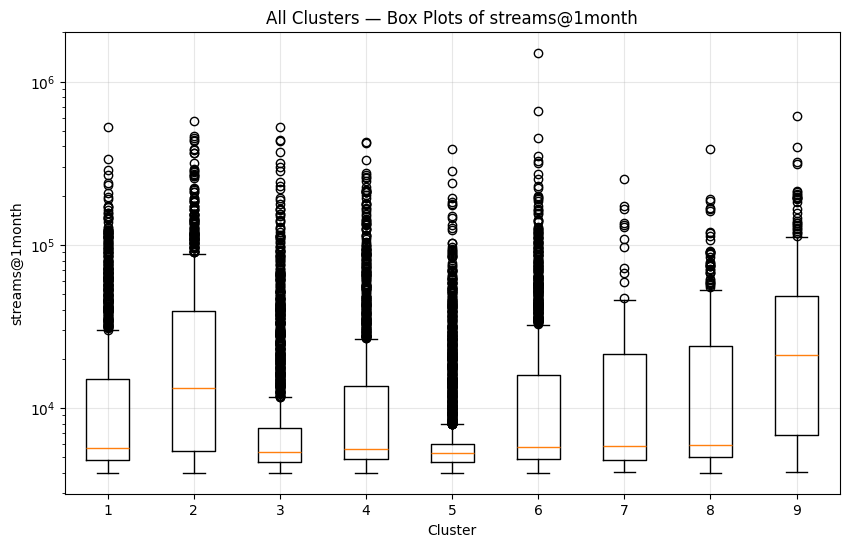

In [20]:
from statistics import mean, stdev
import numpy as np
import matplotlib.pyplot as plt

# Collect data in one structure for the combined plot
all_stream_distributions = []

for cluster in range(len(clusters)):
    streams = [track['streams@1month'] for track in clusters[cluster]]
    all_stream_distributions.append(streams)

    print(f'Cluster {cluster} avg streams@1month:\t\t{mean(streams)}')
    print(f'\tStandard Deviation:\t\t{stdev(streams)}\n')

# ---- Combined Box Plot ----
plt.figure(figsize=(10, 6))
plt.boxplot(all_stream_distributions, vert=True, showfliers=True)

plt.title("All Clusters — Box Plots of streams@1month")
plt.xlabel("Cluster")
plt.ylabel("streams@1month")
plt.grid(alpha=0.3)

plt.yscale('log')
plt.show()
